In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
np.random.seed(42)  # for reproducible randomness

alpha = 0.1          # learning rate
true_reward_prob = 0.7   # the "true" probability of getting a reward = 1 (vs 0)
n_trials = 200

V = 0.0               # start with no expectation at all
V_trace = np.zeros(n_trials)
RPE_trace = np.zeros(n_trials)
reward_trace = np.zeros(n_trials)

for trial in range(n_trials):
    R = 1.0 if np.random.rand() < true_reward_prob else 0.0  # actual reward this trial
    RPE = R - V                # reward prediction error
    V = V + alpha * RPE        # update belief

    V_trace[trial] = V
    RPE_trace[trial] = RPE
    reward_trace[trial] = R

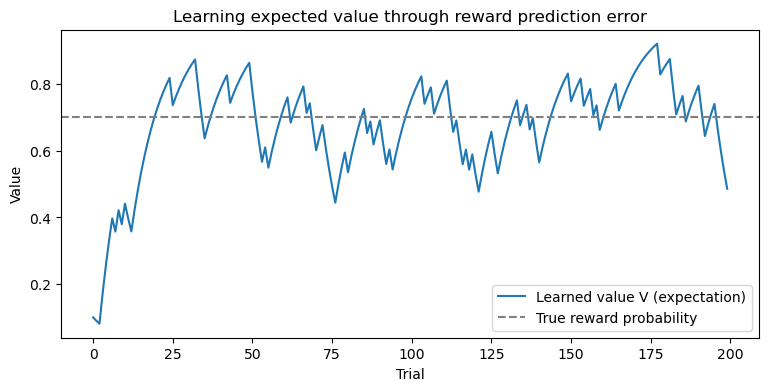

In [3]:
plt.figure(figsize=(9,4))
plt.plot(V_trace, label='Learned value V (expectation)')
plt.axhline(true_reward_prob, color='gray', linestyle='--', label='True reward probability')
plt.xlabel("Trial")
plt.ylabel("Value")
plt.title("Learning expected value through reward prediction error")
plt.legend()
plt.show()

In [4]:
def simulate_learning(alpha, n_trials=200, true_reward_prob=0.7, seed=42):
    np.random.seed(seed)
    V = 0.0
    V_trace = np.zeros(n_trials)
    for trial in range(n_trials):
        R = 1.0 if np.random.rand() < true_reward_prob else 0.0
        RPE = R - V
        V = V + alpha * RPE
        V_trace[trial] = V
    return V_trace

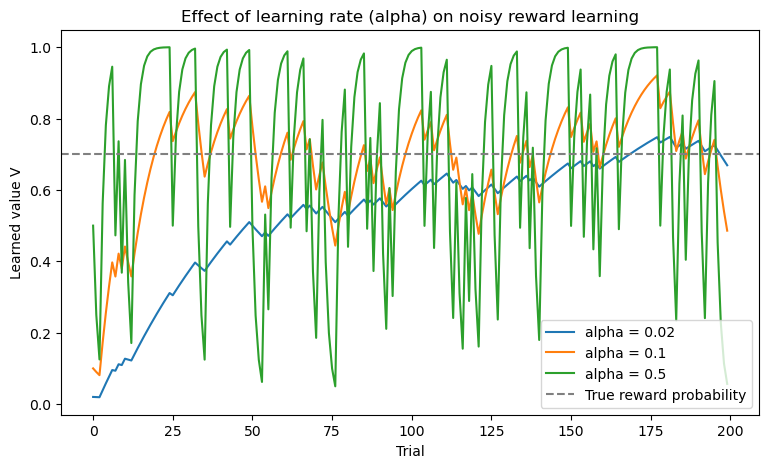

In [5]:
plt.figure(figsize=(9,5))
for a in [0.02, 0.1, 0.5]:
    V_trace = simulate_learning(alpha=a)
    plt.plot(V_trace, label=f'alpha = {a}')

plt.axhline(0.7, color='gray', linestyle='--', label='True reward probability')
plt.xlabel("Trial")
plt.ylabel("Learned value V")
plt.title("Effect of learning rate (alpha) on noisy reward learning")
plt.legend()
plt.show()

In [6]:
def softmax_choice(V_A, V_B, tau=0.3):
    p_A = np.exp(V_A / tau) / (np.exp(V_A / tau) + np.exp(V_B / tau))
    return p_A

def two_armed_bandit(alpha=0.1, tau=0.3, n_trials=200,
                      true_prob_A=0.7, true_prob_B=0.3, seed=42):
    np.random.seed(seed)
    V_A, V_B = 0.0, 0.0  # start with no expectations for either arm

    V_A_trace = np.zeros(n_trials)
    V_B_trace = np.zeros(n_trials)
    choice_trace = np.zeros(n_trials)  # 1 = chose A, 0 = chose B
    RPE_trace = np.zeros(n_trials)

    for trial in range(n_trials):
        p_A = softmax_choice(V_A, V_B, tau)
        choice = 'A' if np.random.rand() < p_A else 'B'

        if choice == 'A':
            R = 1.0 if np.random.rand() < true_prob_A else 0.0
            RPE = R - V_A
            V_A = V_A + alpha * RPE
            choice_trace[trial] = 1
        else:
            R = 1.0 if np.random.rand() < true_prob_B else 0.0
            RPE = R - V_B
            V_B = V_B + alpha * RPE
            choice_trace[trial] = 0

        V_A_trace[trial] = V_A
        V_B_trace[trial] = V_B
        RPE_trace[trial] = RPE

    return V_A_trace, V_B_trace, choice_trace, RPE_trace

V_A_trace, V_B_trace, choice_trace, RPE_trace = two_armed_bandit()

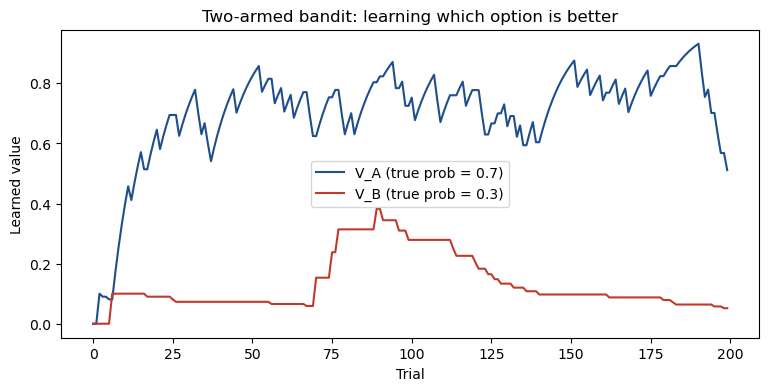

In [7]:
plt.figure(figsize=(9,4))
plt.plot(V_A_trace, label='V_A (true prob = 0.7)', color='#1f4e8c')
plt.plot(V_B_trace, label='V_B (true prob = 0.3)', color='#c0392b')
plt.xlabel("Trial")
plt.ylabel("Learned value")
plt.title("Two-armed bandit: learning which option is better")
plt.legend()
plt.show()

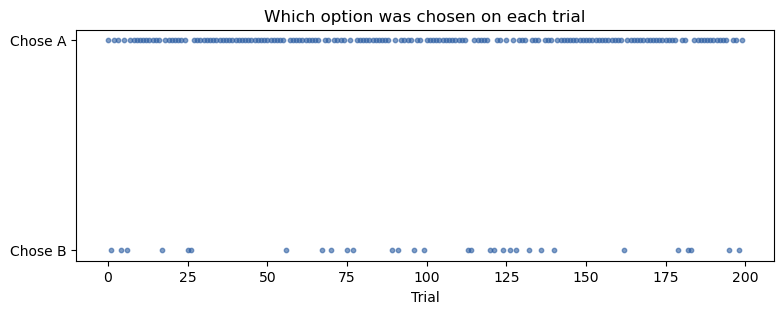

Chose A on 169 out of 200 trials


In [8]:
plt.figure(figsize=(9,3))
plt.scatter(range(len(choice_trace)), choice_trace, s=10, alpha=0.6, color='#2e5fa3')
plt.yticks([0, 1], ['Chose B', 'Chose A'])
plt.xlabel("Trial")
plt.title("Which option was chosen on each trial")
plt.show()

print(f"Chose A on {int(choice_trace.sum())} out of {len(choice_trace)} trials")

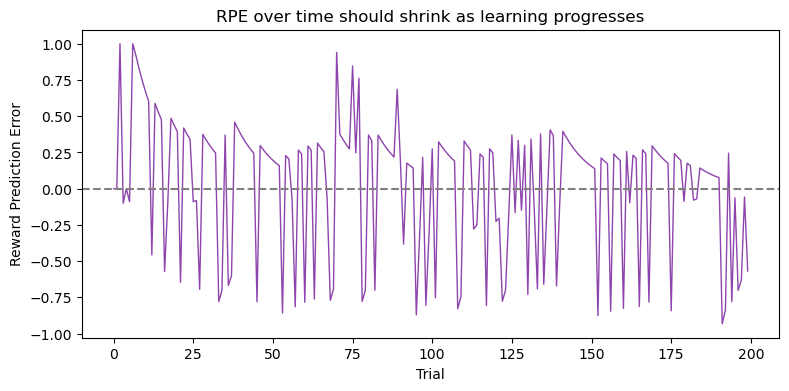

In [10]:
plt.figure(figsize=(9,4))
plt.plot(RPE_trace, color='#8e44ad', linewidth=1)
plt.axhline(0, color='gray', linestyle='--')
plt.xlabel("Trial")
plt.ylabel("Reward Prediction Error")
plt.title("RPE over time should shrink as learning progresses")
plt.show()

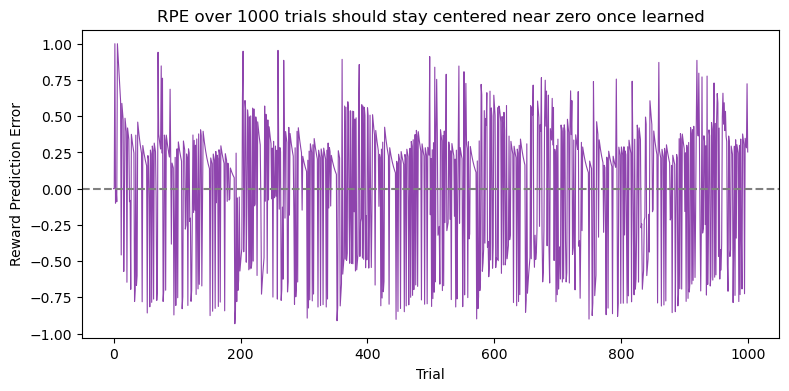

In [11]:
V_A_trace, V_B_trace, choice_trace, RPE_trace = two_armed_bandit(n_trials=1000)

plt.figure(figsize=(9,4))
plt.plot(RPE_trace, color='#8e44ad', linewidth=0.8)
plt.axhline(0, color='gray', linestyle='--')
plt.xlabel("Trial")
plt.ylabel("Reward Prediction Error")
plt.title("RPE over 1000 trials should stay centered near zero once learned")
plt.show()

In [12]:
# Manually set V to represent each scenario, then compute RPE for reward vs no reward

scenarios = {
    "Fully expected reward\n(V=1.0, R=1)": (1.0, 1.0),
    "Unexpected reward\n(V=0.0, R=1)": (0.0, 1.0),
    "Expected reward omitted\n(V=1.0, R=0)": (1.0, 0.0),
}

labels = []
RPEs = []

for label, (V, R) in scenarios.items():
    RPE = R - V
    labels.append(label)
    RPEs.append(RPE)
    print(f"{label.splitlines()[0]}: RPE = {RPE:.2f}")

Fully expected reward: RPE = 0.00
Unexpected reward: RPE = 1.00
Expected reward omitted: RPE = -1.00


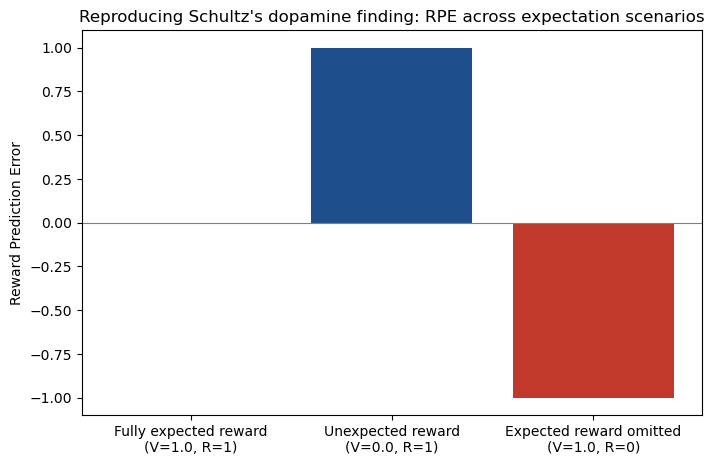

In [13]:
plt.figure(figsize=(8,5))
colors = ['#27ae60' if r == 0 else ('#1f4e8c' if r > 0 else '#c0392b') for r in RPEs]
plt.bar(labels, RPEs, color=colors)
plt.axhline(0, color='gray', linewidth=0.8)
plt.ylabel("Reward Prediction Error")
plt.title("Reproducing Schultz's dopamine finding: RPE across expectation scenarios")
plt.show()